# Backend & Kernel 최적화 실습

### 환경 설정 및 재현성, 백본 및 데이터셋 설정

In [1]:
import os
import random
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [2]:
SEED = 42

def seed_everything(seed=42, deterministic=True):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # 일부 연산이 deterministic 구현을 지원하지 않으면 에러가 날 수 있음
        torch.use_deterministic_algorithms(True)

        # CUDA matmul reproducibility 관련 권장 설정
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


seed_everything(SEED, deterministic=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("seed:", SEED)
print("device:", device)
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("cuda version:", torch.version.cuda)
    print("gpu:", torch.cuda.get_device_name(0))

seed: 42
device: cuda
torch version: 2.5.1+cu121
cuda available: True
cuda version: 12.1
gpu: NVIDIA RTX A6000


In [3]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=g,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=g,
)

print("train samples:", len(train_dataset))
print("test samples:", len(test_dataset))

class SimpleMLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, hidden2)
        self.fc4 = nn.Linear(hidden2, hidden2)
        self.fc5 = nn.Linear(hidden2, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)
        x = F.relu(x)

        x = self.fc4(x)
        x = F.relu(x)

        x = self.fc5(x)

        return x
    
@torch.no_grad()
def evaluate_accuracy(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        pred = logits.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    return correct / total * 100

train samples: 60000
test samples: 10000


In [4]:
model_fp = SimpleMLP(
    hidden1=256,
    hidden2=128,
).to(device).float()

optimizer = torch.optim.AdamW(model_fp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model_fp.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model_fp(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / total
    train_acc = correct / total * 100

    test_acc = evaluate_accuracy(model_fp, test_loader, device)

    print(
        f"epoch {epoch+1:02d} | "
        f"train loss {train_loss:.4f} | "
        f"train acc {train_acc:.2f}% | "
        f"test acc {test_acc:.2f}%"
    )

epoch 01 | train loss 0.3259 | train acc 90.01% | test acc 95.51%
epoch 02 | train loss 0.1162 | train acc 96.40% | test acc 95.32%
epoch 03 | train loss 0.0829 | train acc 97.46% | test acc 96.78%


In [5]:
model_fp.eval()

fp32_acc = evaluate_accuracy(
    model=model_fp,
    loader=test_loader,
    device=device,
)

print(f"FP32 Test Accuracy: {fp32_acc:.2f}%")

FP32 Test Accuracy: 96.78%


In [6]:
save_dir = "./artifacts_mnist_mlp"
os.makedirs(save_dir, exist_ok=True)

ckpt_path = os.path.join(save_dir, "mnist_best_mlp_fp32_state_dict.pt")

torch.save(
    {
        "model_name": "mnist_best_mlp",
        "state_dict": model_fp.state_dict(),
        "fp32_acc": fp32_acc,
    },
    ckpt_path,
)

print("saved:", ckpt_path)

saved: ./artifacts_mnist_mlp/mnist_best_mlp_fp32_state_dict.pt


### 성능 비교 진행

In [7]:
trt_batch_size = 128

test_loader_fixed = DataLoader(
    test_dataset,
    batch_size=trt_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

num_eval_samples = len(test_loader_fixed) * trt_batch_size
print("fixed eval samples:", num_eval_samples)

fixed eval samples: 9984


In [8]:
model_fp = model_fp.to(device).float().eval()

fp32_acc_fixed = evaluate_accuracy(
    model=model_fp,
    loader=test_loader_fixed,
    device=device,
)

print(f"FP32 Accuracy on fixed eval set: {fp32_acc_fixed:.2f}%")

FP32 Accuracy on fixed eval set: 96.77%


In [9]:
@torch.no_grad()
def benchmark_pytorch_model(model, loader, device, dtype=torch.float32, warmup_batches=10):
    model = model.to(device).eval()

    if dtype == torch.float16:
        model = model.half()
    else:
        model = model.float()

    # warmup
    it = iter(loader)
    for _ in range(warmup_batches):
        try:
            x, _ = next(it)
        except StopIteration:
            break

        x = x.to(device)
        if dtype == torch.float16:
            x = x.half()
        else:
            x = x.float()

        _ = model(x)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    total_time = 0.0
    total_samples = 0
    correct = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if dtype == torch.float16:
            x = x.half()
        else:
            x = x.float()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()
        logits = model(x)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.perf_counter()

        pred = logits.float().argmax(dim=1)
        correct += (pred == y).sum().item()
        total_samples += y.size(0)
        total_time += end - start

    acc = correct / total_samples * 100
    latency_ms_per_batch = total_time / len(loader) * 1000
    throughput = total_samples / total_time

    return {
        "accuracy": acc,
        "latency_ms_per_batch": latency_ms_per_batch,
        "throughput_samples_per_sec": throughput,
    }


pt_fp32 = benchmark_pytorch_model(
    model=copy.deepcopy(model_fp),
    loader=test_loader_fixed,
    device=device,
    dtype=torch.float32,
)

pt_fp16 = benchmark_pytorch_model(
    model=copy.deepcopy(model_fp),
    loader=test_loader_fixed,
    device=device,
    dtype=torch.float16,
)

pt_fp32, pt_fp16

({'accuracy': 96.77483974358975,
  'latency_ms_per_batch': 1.9514285153351152,
  'throughput_samples_per_sec': 65592.97406700999},
 {'accuracy': 96.77483974358975,
  'latency_ms_per_batch': 1.9891261367891464,
  'throughput_samples_per_sec': 64349.86581927782})

In [10]:
onnx_path = os.path.join(save_dir, "mnist_best_mlp_fp32.onnx")

model_export = copy.deepcopy(model_fp).to("cuda" if torch.cuda.is_available() else "cpu").float().eval()

dummy_input = torch.randn(
    trt_batch_size,
    1,
    28,
    28,
    device=next(model_export.parameters()).device,
    dtype=torch.float32,
)

torch.onnx.export(
    model_export,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
)

print("saved:", onnx_path)

saved: ./artifacts_mnist_mlp/mnist_best_mlp_fp32.onnx


In [11]:
%pip install pycuda

Note: you may need to restart the kernel to use updated packages.


In [12]:
try:
    import tensorrt as trt
    import pycuda.driver as cuda
    import pycuda.autoinit

    TRT_AVAILABLE = True
    print("TensorRT version:", trt.__version__)
    print("TensorRT / PyCUDA available")

except Exception as e:
    TRT_AVAILABLE = False
    print("TensorRT runner unavailable:", repr(e))

TensorRT version: 10.16.1.11
TensorRT / PyCUDA available


In [13]:
def collect_calibration_batches(loader, num_batches=100):
    batches = []

    for batch_idx, (x, _) in enumerate(loader):
        if batch_idx >= num_batches:
            break

        x_np = x.numpy().astype(np.float32)
        batches.append(np.ascontiguousarray(x_np))

    return batches


calibration_batches = collect_calibration_batches(
    train_loader,
    num_batches=100,
)

print("calibration batches:", len(calibration_batches))
print("one batch shape:", calibration_batches[0].shape)

calibration batches: 100
one batch shape: (128, 1, 28, 28)


In [14]:
if TRT_AVAILABLE:
    class MNISTEntropyCalibrator(trt.IInt8EntropyCalibrator2):
        def __init__(self, calibration_batches, cache_file):
            super().__init__()

            self.calibration_batches = calibration_batches
            self.cache_file = cache_file
            self.batch_idx = 0

            self.input_shape = calibration_batches[0].shape
            self.input_nbytes = calibration_batches[0].nbytes
            self.device_input = cuda.mem_alloc(self.input_nbytes)

        def get_batch_size(self):
            return self.input_shape[0]

        def get_batch(self, names):
            if self.batch_idx >= len(self.calibration_batches):
                return None

            batch = self.calibration_batches[self.batch_idx]
            cuda.memcpy_htod(self.device_input, batch)

            self.batch_idx += 1

            return [int(self.device_input)]

        def read_calibration_cache(self):
            if os.path.exists(self.cache_file):
                with open(self.cache_file, "rb") as f:
                    return f.read()
            return None

        def write_calibration_cache(self, cache):
            with open(self.cache_file, "wb") as f:
                f.write(cache)

In [15]:
if TRT_AVAILABLE:
    TRT_LOGGER = trt.Logger(trt.Logger.WARNING)

    def build_trt_engine(
        onnx_path,
        engine_path,
        precision="fp32",
        calibration_batches=None,
        workspace_size_gb=1,
    ):
        assert precision in ["fp32", "fp16", "int8"]

        builder = trt.Builder(TRT_LOGGER)
        network_flags = 1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
        network = builder.create_network(network_flags)
        parser = trt.OnnxParser(network, TRT_LOGGER)

        with open(onnx_path, "rb") as f:
            if not parser.parse(f.read()):
                print("ONNX parse failed")
                for i in range(parser.num_errors):
                    print(parser.get_error(i))
                raise RuntimeError("Failed to parse ONNX")

        config = builder.create_builder_config()

        if hasattr(config, "set_memory_pool_limit"):
            config.set_memory_pool_limit(
                trt.MemoryPoolType.WORKSPACE,
                workspace_size_gb * (1 << 30),
            )
        else:
            config.max_workspace_size = workspace_size_gb * (1 << 30)

        if precision == "fp16":
            if not builder.platform_has_fast_fp16:
                print("[warn] platform_has_fast_fp16 is False")
            config.set_flag(trt.BuilderFlag.FP16)

        if precision == "int8":
            if not builder.platform_has_fast_int8:
                print("[warn] platform_has_fast_int8 is False")
            config.set_flag(trt.BuilderFlag.INT8)

            cache_file = os.path.join(save_dir, "mnist_best_mlp_int8_calibration.cache")
            calibrator = MNISTEntropyCalibrator(
                calibration_batches=calibration_batches,
                cache_file=cache_file,
            )
            config.int8_calibrator = calibrator

        serialized_engine = builder.build_serialized_network(network, config)

        if serialized_engine is None:
            raise RuntimeError(f"Failed to build TensorRT engine: {precision}")

        with open(engine_path, "wb") as f:
            f.write(serialized_engine)

        print(f"saved {precision} engine:", engine_path)

        return engine_path

In [16]:
if TRT_AVAILABLE:
    trt_engine_paths = {}

    for precision in ["fp32", "fp16", "int8"]:
        engine_path = os.path.join(save_dir, f"mnist_best_mlp_trt_{precision}.plan")

        trt_engine_paths[precision] = build_trt_engine(
            onnx_path=onnx_path,
            engine_path=engine_path,
            precision=precision,
            calibration_batches=calibration_batches if precision == "int8" else None,
            workspace_size_gb=1,
        )

    trt_engine_paths

saved fp32 engine: ./artifacts_mnist_mlp/mnist_best_mlp_trt_fp32.plan
saved fp16 engine: ./artifacts_mnist_mlp/mnist_best_mlp_trt_fp16.plan


/tmp/ipykernel_21665/3975439871.py:50: DeprecationWarning: Use Deprecated in TensorRT 10.1. Superseded by explicit quantization. instead.
  config.int8_calibrator = calibrator


saved int8 engine: ./artifacts_mnist_mlp/mnist_best_mlp_trt_int8.plan


In [17]:
if TRT_AVAILABLE:
    class TRTModule:
        def __init__(self, engine_path):
            self.logger = trt.Logger(trt.Logger.WARNING)
            self.runtime = trt.Runtime(self.logger)

            with open(engine_path, "rb") as f:
                engine_bytes = f.read()

            self.engine = self.runtime.deserialize_cuda_engine(engine_bytes)
            self.context = self.engine.create_execution_context()

            self.stream = cuda.Stream()

            self.input_name = None
            self.output_name = None

            for i in range(self.engine.num_io_tensors):
                name = self.engine.get_tensor_name(i)
                mode = self.engine.get_tensor_mode(name)

                if mode == trt.TensorIOMode.INPUT:
                    self.input_name = name
                elif mode == trt.TensorIOMode.OUTPUT:
                    self.output_name = name

            assert self.input_name is not None
            assert self.output_name is not None

            self.input_shape = tuple(self.engine.get_tensor_shape(self.input_name))
            self.output_shape = tuple(self.engine.get_tensor_shape(self.output_name))

            self.input_dtype = trt.nptype(self.engine.get_tensor_dtype(self.input_name))
            self.output_dtype = trt.nptype(self.engine.get_tensor_dtype(self.output_name))

            self.host_input = np.empty(self.input_shape, dtype=self.input_dtype)
            self.host_output = np.empty(self.output_shape, dtype=self.output_dtype)

            self.device_input = cuda.mem_alloc(self.host_input.nbytes)
            self.device_output = cuda.mem_alloc(self.host_output.nbytes)

            self.context.set_tensor_address(self.input_name, int(self.device_input))
            self.context.set_tensor_address(self.output_name, int(self.device_output))

        def __call__(self, x_np):
            x_np = np.ascontiguousarray(x_np.astype(self.input_dtype))

            np.copyto(self.host_input, x_np)

            cuda.memcpy_htod_async(self.device_input, self.host_input, self.stream)
            self.context.execute_async_v3(stream_handle=self.stream.handle)
            cuda.memcpy_dtoh_async(self.host_output, self.device_output, self.stream)
            self.stream.synchronize()

            return self.host_output.copy()

In [18]:
def evaluate_trt_engine(trt_model, loader, warmup_batches=10):
    # warmup
    it = iter(loader)
    for _ in range(warmup_batches):
        try:
            x, _ = next(it)
        except StopIteration:
            break

        x_np = x.numpy().astype(np.float32)
        _ = trt_model(x_np)

    total_time = 0.0
    total_samples = 0
    correct = 0

    for x, y in loader:
        x_np = x.numpy().astype(np.float32)

        start = time.perf_counter()
        logits = trt_model(x_np)
        end = time.perf_counter()

        pred = torch.from_numpy(logits).argmax(dim=1)
        correct += (pred == y).sum().item()

        total_samples += y.size(0)
        total_time += end - start

    acc = correct / total_samples * 100
    latency_ms_per_batch = total_time / len(loader) * 1000
    throughput = total_samples / total_time

    return {
        "accuracy": acc,
        "latency_ms_per_batch": latency_ms_per_batch,
        "throughput_samples_per_sec": throughput,
    }


trt_results = {}

if TRT_AVAILABLE:
    for precision, engine_path in trt_engine_paths.items():
        print(f"[eval] TensorRT {precision}")

        trt_model = TRTModule(engine_path)
        result = evaluate_trt_engine(
            trt_model=trt_model,
            loader=test_loader_fixed,
            warmup_batches=10,
        )

        trt_results[precision] = result
        print(result)

[eval] TensorRT fp32
{'accuracy': 96.77483974358975, 'latency_ms_per_batch': 0.35441105062953937, 'throughput_samples_per_sec': 361162.55340411636}
[eval] TensorRT fp16
[04/28/2026-12:04:04] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
{'accuracy': 96.77483974358975, 'latency_ms_per_batch': 0.4195950071637829, 'throughput_samples_per_sec': 305056.0607601249}
[eval] TensorRT int8
[04/28/2026-12:04:05] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
{'accuracy': 77.52403846153845, 'latency_ms_per_batch': 0.43794701401239783, 'throughput_samples_

In [19]:
def symmetric_quant_dequant_tensor(x_fp32: torch.Tensor, num_bits: int):
    assert x_fp32.dtype == torch.float32
    assert 2 <= num_bits <= 8

    qmax = 2 ** (num_bits - 1) - 1
    qmin = -qmax

    max_abs = x_fp32.abs().max()

    if max_abs == 0:
        return x_fp32.clone()

    scale = max_abs / qmax

    x_int = torch.round(x_fp32 / scale)
    x_int = torch.clamp(x_int, qmin, qmax)

    x_dequant = x_int * scale

    return x_dequant


def apply_weight_only_qdq(model_fp, num_bits):
    model_q = copy.deepcopy(model_fp).eval().float()

    with torch.no_grad():
        for name, module in model_q.named_modules():
            if isinstance(module, nn.Linear):
                w_fp32 = module.weight.data.float()
                w_qdq = symmetric_quant_dequant_tensor(w_fp32, num_bits)
                module.weight.data.copy_(w_qdq)

    return model_q


int4_model = apply_weight_only_qdq(model_fp, 4).to(device).eval()
int2_model = apply_weight_only_qdq(model_fp, 2).to(device).eval()

pt_int4 = benchmark_pytorch_model(
    model=int4_model,
    loader=test_loader_fixed,
    device=device,
    dtype=torch.float32,
)

pt_int2 = benchmark_pytorch_model(
    model=int2_model,
    loader=test_loader_fixed,
    device=device,
    dtype=torch.float32,
)

pt_int4, pt_int2

({'accuracy': 96.53445512820514,
  'latency_ms_per_batch': 2.0282487235724544,
  'throughput_samples_per_sec': 63108.63086581773},
 {'accuracy': 10.286458333333332,
  'latency_ms_per_batch': 1.9015670121193695,
  'throughput_samples_per_sec': 67312.90519040877})

### 시각화


In [20]:
rows = []

rows.append({
    "model": "fp32",
    "backend": "PyTorch CUDA",
    "precision": "fp32",
    "accuracy": pt_fp32["accuracy"],
    "accuracy_drop_vs_fp32": fp32_acc_fixed - pt_fp32["accuracy"],
    "latency_ms_per_batch": pt_fp32["latency_ms_per_batch"],
    "throughput_samples_per_sec": pt_fp32["throughput_samples_per_sec"],
    "note": "PyTorch baseline",
})

rows.append({
    "model": "fp16",
    "backend": "PyTorch CUDA",
    "precision": "fp16",
    "accuracy": pt_fp16["accuracy"],
    "accuracy_drop_vs_fp32": fp32_acc_fixed - pt_fp16["accuracy"],
    "latency_ms_per_batch": pt_fp16["latency_ms_per_batch"],
    "throughput_samples_per_sec": pt_fp16["throughput_samples_per_sec"],
    "note": "PyTorch baseline",
})

if TRT_AVAILABLE:
    for precision in ["fp32", "fp16", "int8"]:
        result = trt_results[precision]

        rows.append({
            "model": precision,
            "backend": "TensorRT",
            "precision": precision,
            "accuracy": result["accuracy"],
            "accuracy_drop_vs_fp32": fp32_acc_fixed - result["accuracy"],
            "latency_ms_per_batch": result["latency_ms_per_batch"],
            "throughput_samples_per_sec": result["throughput_samples_per_sec"],
            "note": "TensorRT engine",
        })

rows.append({
    "model": "int4",
    "backend": "PyTorch QDQ",
    "precision": "int4 weight-only qdq",
    "accuracy": pt_int4["accuracy"],
    "accuracy_drop_vs_fp32": fp32_acc_fixed - pt_int4["accuracy"],
    "latency_ms_per_batch": pt_int4["latency_ms_per_batch"],
    "throughput_samples_per_sec": pt_int4["throughput_samples_per_sec"],
    "note": "Not TensorRT optimized; QDQ accuracy reference",
})

rows.append({
    "model": "int2",
    "backend": "PyTorch QDQ",
    "precision": "int2 weight-only qdq",
    "accuracy": pt_int2["accuracy"],
    "accuracy_drop_vs_fp32": fp32_acc_fixed - pt_int2["accuracy"],
    "latency_ms_per_batch": pt_int2["latency_ms_per_batch"],
    "throughput_samples_per_sec": pt_int2["throughput_samples_per_sec"],
    "note": "Not TensorRT optimized; QDQ accuracy reference",
})

result_df = pd.DataFrame(rows)
display(result_df)

,model,backend,precision,accuracy,accuracy_drop_vs_fp32,latency_ms_per_batch,throughput_samples_per_sec,note
0,fp32,PyTorch CUDA,fp32,96.774840,0.000000,1.951429,65592.974067,PyTorch baseline
1,fp16,PyTorch CUDA,fp16,96.774840,0.000000,1.989126,64349.865819,PyTorch baseline
2,fp32,TensorRT,fp32,96.774840,0.000000,0.354411,361162.553404,TensorRT engine
3,fp16,TensorRT,fp16,96.774840,0.000000,0.419595,305056.060760,TensorRT engine
4,int8,TensorRT,int8,77.524038,19.250801,0.437947,292272.799915,TensorRT engine
5,int4,PyTorch QDQ,int4 weight-only qdq,96.534455,0.240385,2.028249,63108.630866,Not TensorRT optimized; QDQ accuracy reference
6,int2,PyTorch QDQ,int2 weight-only qdq,10.286458,86.488381,1.901567,67312.905190,Not TensorRT optimized; QDQ accuracy reference


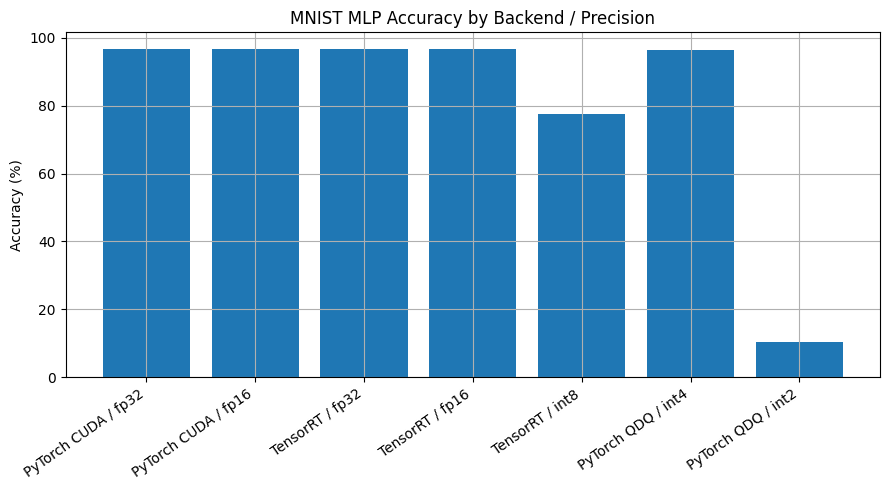

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(
    result_df["backend"] + " / " + result_df["model"],
    result_df["accuracy"],
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("MNIST MLP Accuracy by Backend / Precision")
plt.grid(True)
plt.tight_layout()
plt.show()

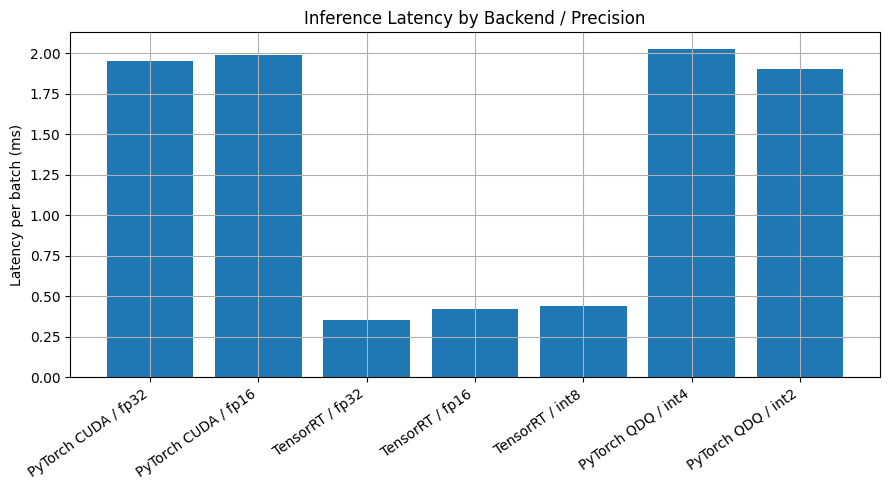

In [22]:
plt.figure(figsize=(9, 5))
plt.bar(
    result_df["backend"] + " / " + result_df["model"],
    result_df["latency_ms_per_batch"],
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Latency per batch (ms)")
plt.title("Inference Latency by Backend / Precision")
plt.grid(True)
plt.tight_layout()
plt.show()